# Random Forest: Training and Evaluation

This notebook trains a Random Forest classifier on preprocessed heart disease data and reports:
- Hyperparameter tuning via GridSearchCV
- K-Fold cross-validation
- Accuracy, Precision, Recall, F1-score, AUC-ROC
- Confusion Matrix, ROC Curve
- Feature importance (bar chart)

In [13]:
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("matplotlib") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
)

# Load preprocessed train/test data
train_df = pd.read_csv("heart_train_preprocessed.csv")
test_df = pd.read_csv("heart_test_preprocessed.csv")

X_train = train_df.drop(columns=["target"])
y_train = train_df["target"]
X_test = test_df.drop(columns=["target"])
y_test = test_df["target"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (241, 30)
Test shape: (61, 30)


## 1. Hyperparameter Tuning with GridSearchCV

In [14]:
# Define hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [3, 5, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV F1-score: {grid_search.best_score_:.4f}")

Best Parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best CV F1-score: 0.8647


## 2. Model Evaluation

In [15]:
# Use the best model from grid search
model = grid_search.best_estimator_

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_proba)

print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"F1-score    : {f1:.4f}")
print(f"AUC-ROC     : {auc_roc:.4f}")

Accuracy    : 0.8197
Precision   : 0.8235
Recall      : 0.8485
F1-score    : 0.8358
AUC-ROC     : 0.8820


## 3. K-Fold Cross-Validation

In [16]:
# 5-fold and 10-fold cross-validation on the tuned model
for k in [5, 10]:
    cv_scores = cross_val_score(model, X_train, y_train, cv=k, scoring="f1")
    print(f"{k}-Fold CV F1-scores: {np.round(cv_scores, 4)}")
    print(f"  Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}\n")

5-Fold CV F1-scores: [0.8727 0.8235 0.8525 0.8519 0.9231]
  Mean: 0.8647  Std: 0.0331

10-Fold CV F1-scores: [0.8966 0.9231 0.88   0.8    0.7586 0.8966 0.7857 0.8889 0.963  0.8   ]
  Mean: 0.8592  Std: 0.0644



## 4. Confusion Matrix & ROC Curve

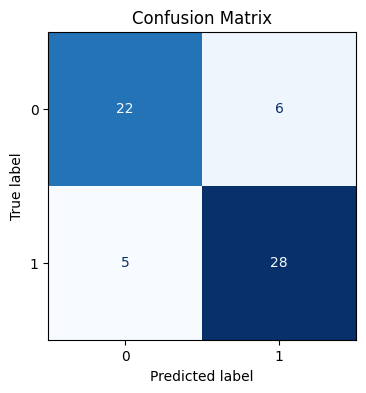

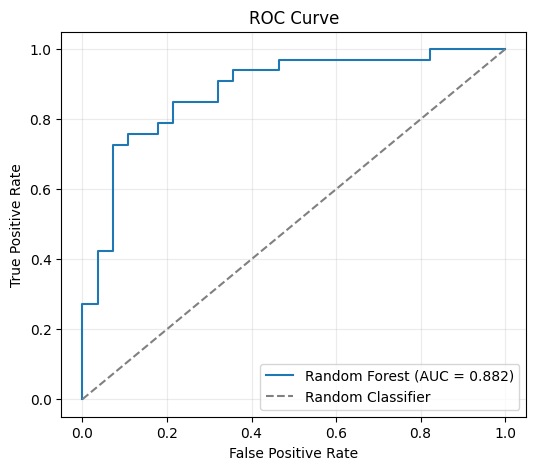

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_roc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.show()

## 5. Feature Importance

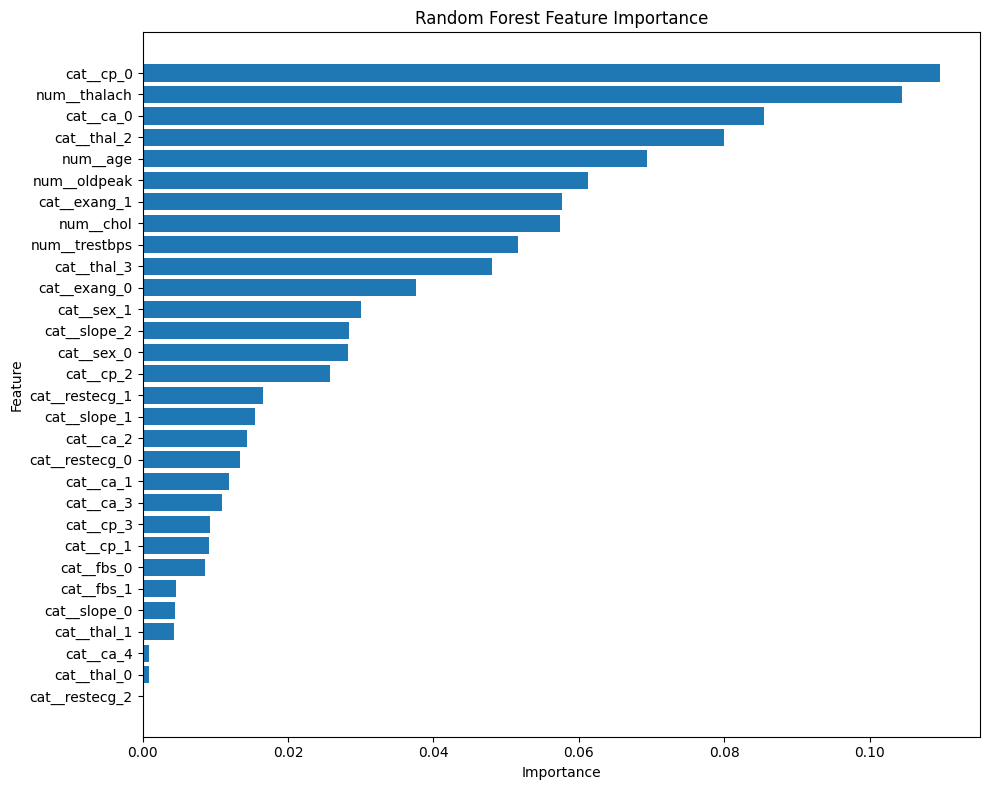

Top 10 important features:


cat__cp_0        0.109680
num__thalach     0.104475
cat__ca_0        0.085416
cat__thal_2      0.079909
num__age         0.069433
num__oldpeak     0.061225
cat__exang_1     0.057634
num__chol        0.057357
num__trestbps    0.051594
cat__thal_3      0.048104
dtype: float64

In [18]:
# Feature importance
importance_series = pd.Series(model.feature_importances_, index=X_train.columns)
importance_sorted = importance_series.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance_sorted.index, importance_sorted.values, color="#1f77b4")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Show top 10 features
print("Top 10 important features:")
display(importance_sorted.head(10))